<h2 align="center"> State changes - Visual Behavior Neuropixels </h2>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> During the task, the mice are visually engaged, interact with their environment, and portray several behavioral profile sequences. Meanwhile, Neuropixels electrodes record spiking activity across the visual cortex and several hippocampal and thalamic nuclei. The behavioral task, therefore, offers an opportunity to study the dynamics of spiking activity during various behavioral states and aids in understanding the behavioral dynamics of task engagement.     
</div>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.stats import norm
import seaborn as sns
import glob

pd.set_option('display.max_columns', None)

%matplotlib inline

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> The <a href="https://portal.brain-map.org/explore/circuits/visual-behavior-neuropixels">Visual Behavior Neuropixels dataset</a> consists of recordings of neural activity measured using 6 Neuropixels probes from mice that have learned to perform an image change detection task.  Recordings are made simultaneously from neurons distributed across layers in the visual cortex ( VISp, VISl, VISal, VISrl, VISam, and VISpm), neurons in the hippocampus (CA1/3, DG), and neurons in the visual thalamus (LP and LGd).
    
<p> In this go/no-go task task, mice are shown a series of visual images that are briefly presented (250 ms) and they earn water rewards by correctly reporting (licking the reward spout) when the identity of the image changes (diagrammed below). 
     
</div>

<img src="Resources/download.png">  

In [2]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache

cache_dir  =  "/data/"

cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir, use_static_cache=True)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
The Visual Behavior Neuropixels dataset is accessed with the Python module `VisualBehaviorNeuropixelsProjectCache`. Path to the NWBs that store the session information from all mice are also provided.
    
</div>

In [3]:
# 1053709239, 1090803859, 1112515874, 1115368723,  1152632711 
example_sessions = [1139846596,  1124507277, 1069461581, 1064644573, 1067790400, 1093642839, 1130113579 ]

session_id = example_sessions[0] 
session = cache.get_ecephys_session(session_id)

trial_metadata = session.trials # 'trials' is a dataframe that contains metadata and task information for each trial
# display(trial_metadata.iloc[100:120].head()) 
display(trial_metadata.iloc[8])

/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.8.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.5.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


start_time                                                                48.6782
stop_time                                                                57.46886
initial_image_name                                                        im104_r
change_image_name                                                         im111_r
is_change                                                                    True
change_time_no_display_delay                                             53.19876
go                                                                          False
catch                                                                       False
lick_times                      [53.89841, 53.96567, 54.08182, 54.21558, 54.31...
response_time                                                            53.89841
reward_time                                                              53.36573
reward_volume                                                               0.005
hit             

In [4]:
stim_table = session.stimulus_presentations
stim_table = stim_table[stim_table['active']] # get active session
stim_table = stim_table[stim_table['trials_id'] != -1] # clean up 

# Merge the two DataFrames based on trial index
merged_df = trial_metadata.drop(columns=['lick_times']).merge(
    stim_table,
    left_index=True,         # Use the index of trial_metadata as the join key
    right_on='trials_id',    # Use the 'trials_id' column of stim_table as the join key
    how='outer',             # Default join type, adjust as needed
)

# Resolve overlapping columns by choosing from trial_metadata (e.g., `_x`) or stim_table (e.g., `_y`)
for col in trial_metadata.columns.intersection(stim_table.columns):
    merged_df[col] = merged_df[f"{col}_y"].combine_first(merged_df[f"{col}_x"])
    merged_df.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)

merged_df = merged_df.rename(columns={'stop_time': 'trial_stop_time'})
stim_table_concat = merged_df
display(stim_table_concat[stim_table_concat.trials_id == 8]) 

,trial_stop_time,initial_image_name,change_image_name,change_time_no_display_delay,go,catch,response_time,reward_time,reward_volume,hit,false_alarm,miss,correct_reject,aborted,auto_rewarded,change_frame,trial_length,active,color,contrast,duration,end_frame,flashes_since_change,image_name,is_image_novel,is_sham_change,omitted,orientation,position_x,position_y,rewarded,spatial_frequency,start_frame,stimulus_block,stimulus_index,stimulus_name,end_time,temporal_frequency,trials_id,start_time,is_change
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
28,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250203,1335,26,im104_r,False,False,False,NaN,NaN,NaN,False,NaN,1320,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,48.973212,NaN,8,48.723008,False
29,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250203,1380,27,im104_r,False,False,False,NaN,NaN,NaN,False,NaN,1365,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,49.723822,NaN,8,49.473618,False
30,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250219,1425,28,im104_r,False,False,False,NaN,NaN,NaN,False,NaN,1410,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,50.474479,NaN,8,50.224260,False
31,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250198,1470,29,im104_r,False,False,False,NaN,NaN,NaN,False,NaN,1455,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,51.225095,NaN,8,50.974897,False
32,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250219,1515,30,im104_r,False,False,False,NaN,NaN,NaN,False,NaN,1500,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,51.975711,NaN,8,51.725492,False
33,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250218,1561,31,im104_r,False,False,False,NaN,NaN,NaN,False,NaN,1546,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,52.743049,NaN,8,52.492831,False
34,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250201,1606,0,im111_r,False,False,False,NaN,NaN,NaN,True,NaN,1591,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,53.493651,NaN,8,53.243450,True
35,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250209,1651,1,im111_r,False,False,False,NaN,NaN,NaN,False,NaN,1636,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,54.244271,NaN,8,53.994061,False
36,57.46886,im104_r,im111_r,53.19876,False,False,53.89841,53.36573,0.005,False,False,False,False,False,True,1591,8.79066,True,NaN,NaN,0.250208,1696,2,im111_r,False,False,False,NaN,NaN,NaN,False,NaN,1681,0,-99,Natural_Images_Lum_Matched_set_ophys_H_2019,54.994897,NaN,8,54.744689,False


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
How well does the mouse recognize a change in the image sequences? We can quantify their performance by evaluating the fraction of 'go' trials during which the mouse licked the spout.      
</div>

In [5]:
num_go_trials = len(np.where(trial_metadata.go)[0])
num_go_hit_trials = len(np.where(trial_metadata.go[trial_metadata.hit])[0])
print('Proportion of trials correctly performed: ' + str(np.round(num_go_hit_trials/num_go_trials, 2)))

Proportion of trials correctly performed: 0.46


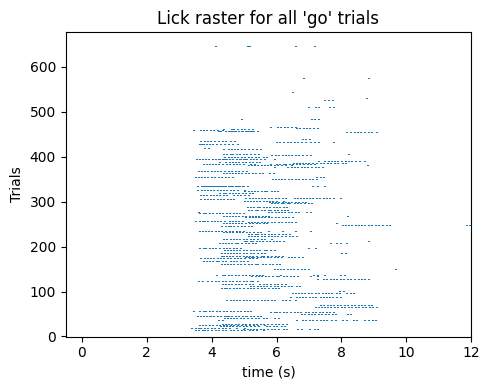

In [6]:
# plot licking patterns for each 'go' trial to get a sense of when they are failing to respond.

# Get lick times for each 'go' trial. Note: we subtract the trial start time so lick times are relative to trial start
lick_times = trial_metadata[trial_metadata.go].lick_times.values - trial_metadata[trial_metadata.go].start_time.values

# Get 'go' trial numbers
go_trials =  trial_metadata[trial_metadata.go].index

# generate plot
fig, ax = plt.subplots(figsize = (5, 4))
ax.eventplot(lick_times, linelength = 1.5, lineoffsets = go_trials);

# Add labels to plot
ax.set_ylim(-0.5, go_trials[-1]+4)
ax.set_xlim(-0.5, 12)
ax.set_ylabel('Trials')
ax.set_xlabel('time (s)')
ax.set_title("Lick raster for all 'go' trials")
plt.tight_layout()

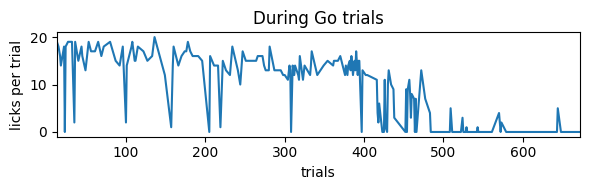

In [7]:
fig, ax = plt.subplots(figsize = (6, 2))

# Select 'go' trials
lick_count = trial_metadata[trial_metadata.go].apply(lambda row : len(row['lick_times']), axis = 1)

# Plot lick rate
ax.plot(lick_count)

# Formatting
ax.set_ylabel('licks per trial')
ax.set_xlabel('trials')
ax.set_xlim(go_trials[0], go_trials[-1])
ax.set_title('During Go trials')
plt.tight_layout()

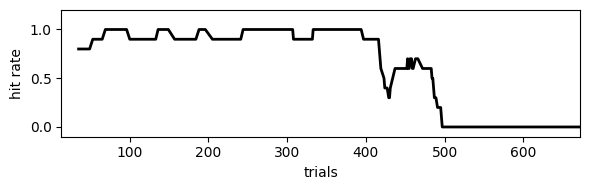

In [8]:
# Compute hit rate with 10 trial rolling window.
hit_rate = trial_metadata.hit[trial_metadata.go].rolling(10).mean()

fig,ax = plt.subplots(figsize = (6, 2)) 
ax.plot(go_trials, hit_rate, color = 'k', lw = 2)

# Formatting
ax.set_xlim(go_trials[0], go_trials[-1])
ax.set_ylim(-0.1, 1.2)
ax.set_xlabel('trials')
ax.set_ylabel('hit rate')

plt.tight_layout()

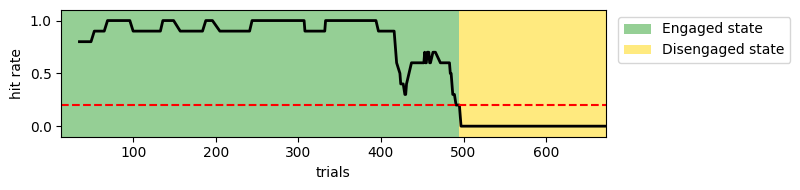

In [9]:
# Threshold for defining engageded vs disengaged states
engagement_threshold = 0.2

fig,ax = plt.subplots(figsize = (8.2, 2)) 
ax.plot(go_trials, hit_rate, color = 'k', lw = 2)
ax.plot(go_trials, engagement_threshold*np.ones(num_go_trials), color = 'r', ls = '--')

# Determine state transition boundaries
states = hit_rate < engagement_threshold
switch_trials = np.where(np.diff(states.values))[0]
switch_trials = np.concatenate(([0], switch_trials, [num_go_trials-1]))

# Plot boundaries to mark state transitions
for i, trial in enumerate(switch_trials[:-1]):
    if not states.values[trial+1]: 
        ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='tab:green', alpha=0.5, label = 'Engaged state')
    else:
        ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='gold', alpha=0.5,label = 'Disengaged state')

# Formatting
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(go_trials[0], go_trials[-1])
ax.set_xlabel('trials')
ax.set_ylabel('hit rate')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor = (1.01, 1))
plt.tight_layout()

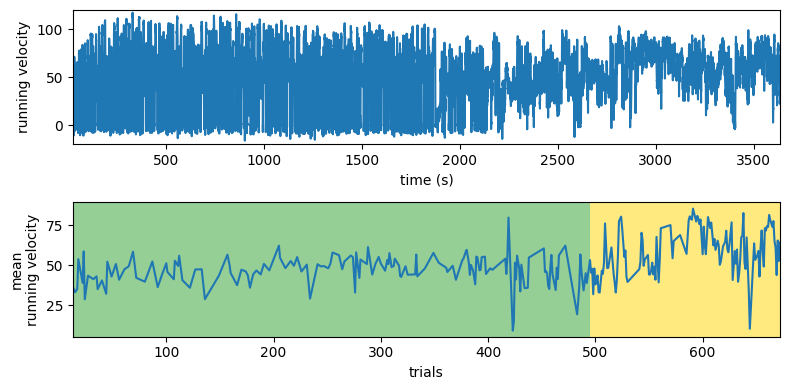

In [10]:
# Get running speed and corresponding timestamps
running_time = session.running_speed.timestamps
running_speed = session.running_speed.speed

stop_time = trial_metadata.stop_time.max()
start_time = trial_metadata.start_time.min()


# Plot running speed
fig,ax = plt.subplots(2,1, figsize = (8, 4)) 
ax[0].plot(running_time, running_speed)
    
# Formatting
ax[0].set_xlim(start_time, stop_time)
ax[0].set_ylim(-20, 120)
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('running velocity');

# Get timestamps corresponding to go trials
trial_start = trial_metadata.start_time[np.where(trial_metadata.go)[0]]
trial_stop = trial_metadata.stop_time[np.where(trial_metadata.go)[0]]

# Compute mean running speed in each go trial
mean_speed = [np.nanmean(running_speed[np.logical_and(s1 <= running_time, running_time <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]

# Plot mean speed
ax[1].plot(go_trials, mean_speed)

# Plot boundaries to mark state transitions
for i, trial in enumerate(switch_trials[:-1]):
    if not states.values[trial+1]: 
        ax[1].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='tab:green', alpha=0.5)
    else:
        ax[1].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='gold', alpha=0.5)

# Formatting
ax[1].set_xlabel('trials')
ax[1].set_ylabel('mean\nrunning velocity')
ax[1].set_xlim(go_trials[0], go_trials[-1])
plt.tight_layout()

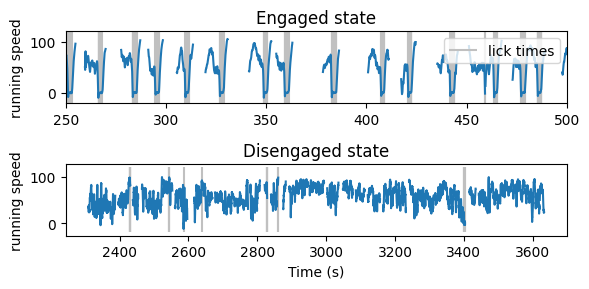

In [11]:
# Get lick times for each 'go' trial and assign values for engaged and disengaged trials into separate dataframes

def flatten(l):
    # function to flatten a list of lists 
    return np.array([item for sublist in l for item in sublist])

engaged_speed = []
disengaged_speed =[]

engaged_time = []
disengaged_time =[]

# Accumulate running speed values for engaged and disengaged trials into separate lists
for index, state in states.items():
    t_start = trial_metadata.iloc[index].start_time
    t_stop = trial_metadata.iloc[index].stop_time
    t = np.where((running_time >= t_start) & (running_time <= t_stop))[0]
    if not state:
        engaged_speed.append(running_speed[t])
        engaged_time.append(running_time[t])
    else:
        disengaged_speed.append(running_speed[t])
        disengaged_time.append(running_time[t])

lick_times = trial_metadata[trial_metadata.go].lick_times
engaged_lick_times = lick_times[~states.values]
disengaged_lick_times = lick_times[states.values]

fig, ax = plt.subplots(2, 1, figsize = (6, 3))

# Plot for engaged state
for time, speed in zip(engaged_time, engaged_speed):
    ax[0].plot(time, speed, color = 'tab:blue')

# Formatting
ax[0].vlines(flatten(engaged_lick_times.values), ymax = 120, ymin = -20, color = 'silver', label = 'lick times')
ax[0].set_ylim(-20, 120)
ax[0].set_xlim(250,500)
ax[0].legend(loc = 'upper right')
ax[0].set_ylabel('running speed')
ax[0].set_title('Engaged state')

# Plot for disengaged state
ax[1].set_title('Disengaged state')
for time, speed in zip(disengaged_time, disengaged_speed):
    ax[1].plot(time, speed, color = 'tab:blue')
    
# Formatting
ax[1].vlines(flatten(disengaged_lick_times.values), ymax = 120, ymin = -20, color = 'silver', label = 'lick times')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylim(-20, 120)
# ax[1].set_xlim(3000,3250) # change limits for different mice
ax[1].set_ylabel('running speed')
plt.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> Mice seem to be stopping (running speed = 0) a lot more in the engaged state. To see why, we can look at the running speeds during engaged states. 
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> To avoid the effect of licking on behavioral movements, lets look only at the pre-change period. 
</div>

In [12]:
# Identify all prechange presentations

change_inds = stim_table_concat[stim_table_concat['is_change']].index.values
stim_table_concat['is_prechange'] = False
stim_table_concat.loc[change_inds-1, 'is_prechange'] = True

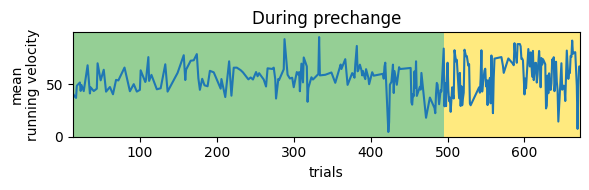

In [13]:

# Get timestamps corresponding to prechange trials
trial_start = stim_table_concat[stim_table_concat.is_prechange].start_time.values
trial_stop = stim_table_concat[stim_table_concat.is_change].start_time.values
pre_change_trials = stim_table_concat[stim_table_concat.is_prechange].trials_id.values

# Compute mean running speed in each go trial
mean_speed = [np.nanmean(running_speed[np.logical_and(s1 <= running_time, running_time <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]
fig, ax = plt.subplots(figsize = (6, 2))
ax.plot(pre_change_trials, mean_speed)

# Plot boundaries to mark state transitions
for i, trial in enumerate(switch_trials[:-1]):
    if not states.values[trial+1]: 
        ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='tab:green', alpha=0.5)
    else:
        ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='gold', alpha=0.5)

# Formatting
ax.set_xlabel('trials')
ax.set_ylabel('mean\nrunning velocity')
ax.set_xlim(go_trials[0], go_trials[-1])
ax.set_title('During prechange')

plt.tight_layout()
plt.show()

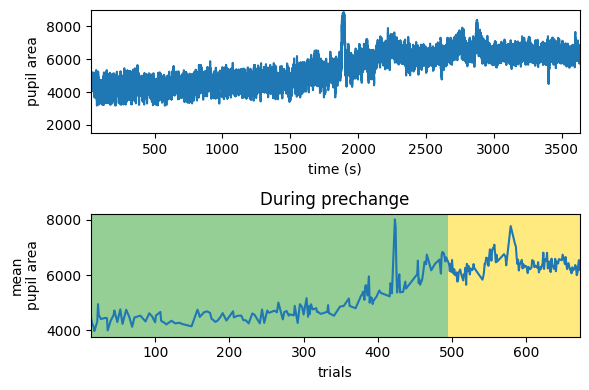

In [14]:
# Get pupil size and associated timestamps
pupil_time = session.eye_tracking.timestamps
pupil_area = session.eye_tracking.pupil_area

# Plot pupil size
fig,ax = plt.subplots(2,1,figsize = (6, 4))
ax[0].plot(pupil_time, pupil_area)

# Formatting
ax[0].set_xlim(start_time, stop_time)
ax[0].set_ylim(1500, 9000)
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('pupil area')

# Get timestamps corresponding to prechange trials
trial_start = stim_table_concat[stim_table_concat.is_prechange].start_time.values
trial_stop = stim_table_concat[stim_table_concat.is_change].start_time.values
pre_change_trials = stim_table_concat[stim_table_concat.is_prechange].trials_id.values

# Compute mean pupil size in each go trial
mean_pupil_area = [np.nanmean(pupil_area[np.logical_and(s1 <= pupil_time, pupil_time <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]
mean_pupil_area = pd.Series(mean_pupil_area).interpolate(method='linear').tolist()
# Plot mean pupil size
ax[1].plot(pre_change_trials , mean_pupil_area)

# Plot boundaries to mark state transitions
for i, trial in enumerate(switch_trials[:-1]):
    if not states.values[trial+1]: 
        ax[1].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='tab:green', alpha=0.5)
    else:
        ax[1].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='gold', alpha=0.5)


# Formatting
ax[1].set_xlabel('trials')
ax[1].set_ylabel('mean\npupil area')
ax[1].set_xlim(go_trials[0], go_trials[-1])
ax[1].set_title('During prechange')
plt.tight_layout()

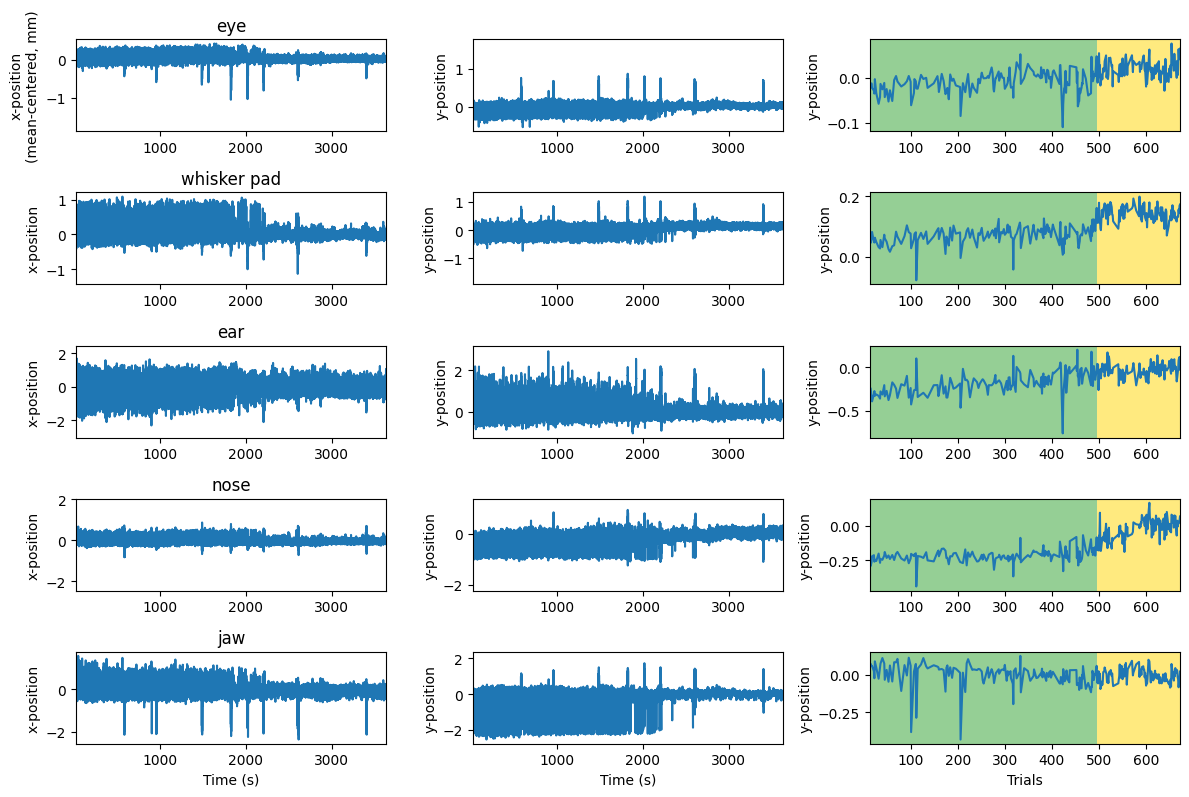

In [15]:
# facial expressions
from scipy.signal import savgol_filter

def part_info_LP(part_name, df, temp_norm):

    confidence = df[part_name , 'likelihood'].values.astype('float')
    x_c = df[part_name , 'x'].values.astype('float')
    y_c = df[part_name , 'y'].values.astype('float')
    xy_c = np.sqrt(x_c ** 2 + (492-y_c) ** 2)

    x_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    x = pd.Series(x_c).interpolate(limit_direction='both').to_numpy()
    
    y_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    y = 492 - pd.Series(y_c).interpolate(limit_direction='both').to_numpy()
    
    xy_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    xy = pd.Series(xy_c).interpolate(limit_direction='both').to_numpy()
    
    # return savgol_filter(x, 11, 3), savgol_filter(y, 11, 3), savgol_filter(xy, 11, 3)
    return x, y, xy
    

pose_tracking_path = '/root/capsule/data/pose_tracking/outputs/video_preds/'

face_keys = ['eye_bottom_l','whisker_pad_l_side', 'ear_base_l', 'nose_tip', 'jaw']
part_names = ['eye', 'whisker pad', 'ear', 'nose', 'jaw']

# Read the CSV file
df_pose_tracking = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id}*behavior.csv')[0], header=[0, 1, 2])
df_pose_tracking = df_pose_tracking.droplevel(0, axis=1)

temporal_norm = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id}*norm.csv')[0])

# get timestamps for video
timestamps_path = '/root/capsule/data/VBN_video_timestamps/'
timestamps = np.load(glob.glob(f'{timestamps_path}/{session_id}*side.npy')[0])

# Print the keys to check the new MultiIndex
fig, ax = plt.subplots(len(face_keys), 3, figsize = (12, 8))
for kno, key_name in enumerate(face_keys): 
    x, y, xy = part_info_LP(key_name, df_pose_tracking, temporal_norm[key_name].values)
    x, y = x*0.242, y*0.242 # convert to mm
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    
    ax[kno, 0].plot(timestamps, x)
    ax[kno, 1].plot(timestamps, y)
    
    # Formatting
    ax[kno, 0].set_xlim(start_time, stop_time)
    ax[kno, 1].set_xlim(start_time, stop_time)

    if kno == 0:
        ax[kno, 0].set_ylabel('x-position\n(mean-centered, mm)')
    else: 
        ax[kno, 0].set_ylabel('x-position')
    ax[kno, 1].set_ylabel('y-position')
    ax[kno, 0].set_title(f'{part_names[kno]}', loc='center', fontsize=12)
    
    
    # Get timestamps corresponding to prechange trials
    trial_start = stim_table_concat[stim_table_concat.is_prechange].start_time.values
    trial_stop = stim_table_concat[stim_table_concat.is_change].start_time.values
    pre_change_trials = stim_table_concat[stim_table_concat.is_prechange].trials_id.values

    # Compute mean position in each go trial
    mean_key_position = [np.nanmean(y[np.logical_and(s1 <= timestamps, timestamps <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]
    
    # pre-change
    ax[kno, 2].plot(pre_change_trials, mean_key_position)
    
    # Plot boundaries to mark state transitions
    for i, trial in enumerate(switch_trials[:-1]):
        if not states.values[trial+1]: 
            ax[kno, 2].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='tab:green', alpha=0.5)
        else:
            ax[kno, 2].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='gold', alpha=0.5)
    ax[kno, 2].set_xlim(go_trials[0], go_trials[-1])
    ax[kno, 2].set_ylabel('y-position')
ax[len(face_keys)-1, 0].set_xlabel('Time (s)')
ax[len(face_keys)-1, 1].set_xlabel('Time (s)')
ax[len(face_keys)-1, 2].set_xlabel('Trials')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
   
<p> However, our definition of behavioral states uses a crude thresholding methodology based on only a single variable. While a good starting point, this definition is incomplete. Moreover, we identified other behavioral metrics relevant to state transitions, yet we did not incorporate this information to define the behavioral states. This additional information could help us refine our understanding of behavioral states, introducing multiple latent states that are difficult to observe by simple eyeballing.

<p> In our current analyses, the threshold to define behavioral states "seemed" appropriate for the mouse we studied. However, the same thresholding techniques may not generalize across mice. Disengagement levels and their markers may vary across different mice. So, how can we systematically assess state changes across many mice? 

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h4> Can we use K-means? </h4>

<p> The density plots may remind you of clusters you saw on Day 3, where we used the unsupervised clustering method, K-means, to identify cell types. Should we try the K-means here?
    
<p> K-means is a simple and powerful tool for clustering. Another method similar to Kmeans, but that offers more flexibility in cluster assignment is Gaussian Mixture models (GMM). While K-Means assigns each data point to a single cluster with a deterministic assignment, GMMs allow data points to belong to multiple clusters with varying degrees of membership probabilities, making them more flexible than K-Means. A limitation of Kmeans lies in its assumption of spherical clusters. GMMs clusters can be of different shapes and orientations.These are just some of the differences.
    
<p> Similar to K-Means, GMMs aim to group data points based on similarity, but they introduce a probabilistic framework. Let us see how we draw a link from k-means clustering to GMMs. By making this connection, we will introduce a new tool to your toolbox: the notion of a mixture model which maximizes the likelihood of the observed data.
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h3> K-means and Gaussian Mixture Models</h3>
    
<p> First, lets sort out our notation: 
<br> <b> Constants</b> 
    <ul>
        <li>$N$ - number of data points. </li>
        <li>$K$ - number of clusters/components </li>
    </ul>

<b> Data</b> 
    <ul>
        <li> $\mathbf{X} = \{x_{n}\}_{n=1}^N$ where $x_n \in \mathbb{R}^{D}$ is the $n^{th}$ data point </li>
    </ul>
    
<b> Latent Variables </b> 
    <ul>
        <li>$\mathbf{Z} = \{z_{n}\}_{n=1}^N$ wher $z_n \in \{1, ..., K\}$ is the cluster assignment for the $n^{th}$ data point </li>
    </ul>
    
<b> Parameters</b>   
    <ul> 
        <li> $\boldsymbol{\Theta} = \{\mu_k\}_{k=1}^K$ where $\mu_k \in \mathbb{R}^D$ is the mean of the $k$-th cluster </li>
    </ul>
    
<h4>K-Means</h4>
    K-Means is an algorithm for estimating the latent variables, $\mathbf{Z}$, and the parameters, $\boldsymbol{\Theta}$, given the data, $\mathbf{X}$. The algorithm alternates between two steps,
    <ol>
        <li><b>Assign</b> each data point to the closest cluster:
            \begin{align}
            z_{n} = \underset{k \in \{1,..., K\}}{\text{arg min}} || x_{n} - \mu_{k}||_{2}
            \end{align}
        </li>
        <li><b>Update</b> the parameters to the mean of the assigned data points
            \begin{align}
            \mu_{k} = \frac{1}{N_{k}}\sum_{n = 1}^{K} w_{n,k} x_{n}, 
            \end{align}
            where 
            \begin{align}
            w_{n,k} &= \begin{cases} 1 & \text{if } z_n =k \\ 0 & \text{o/w} \end{cases} \\
            N_k &= \sum_{n=1}^{N} w_{n,k}.
            \end{align}
        </li>
    </ol>
    

We can think of $w_{n,k}$ as the <i>weight</i> or <i>responsibility</i> that data point $n$ assigns to cluster $k$. 
<br>
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h4>Expectation-Maximization (EM)</h4>
Instead, consider the following tweak to K-Means. Instead of setting the weight to 0 or 1, set it to,
\begin{align}
    w_{n,k} &= \frac{\mathcal{N}(x_n \mid \mu_k, I)}{\sum_{j=1}^K \mathcal{N}(x_n \mid \mu_j, I)}
\end{align}
where $\mathcal{N}(x \mid \mu, \Sigma)$ denotes the <b>probability density function (pdf)</b> of a point $x_n$ under a <b>multivariate normal distribution</b> with mean $\mu$ and covariance $\Sigma$.
<br>
Then the resulting algorithm corresponds to the expectation-maximization (EM) algorithm. EM is a generic algorithm of estimating the parameters of latent variable models. In this case, it estimates the parameters $\boldsymbol{\Theta}$ of a Gaussian mixture model.


<h4>Gaussian Mixture Model (GMM)</h4>
A GMM is a probabilistic model that specifies a joint distribution over data and latent variables given parameters, 
\begin{align}
    p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta}) 
    &= \prod_{n=1}^N p(x_n \mid z_n, \boldsymbol{\Theta}) \, p(z_n \mid \boldsymbol{\Theta}) \\
    &= \prod_{n=1}^N \mathcal{N}(x_n \mid \mu_{z_n}, I) \, \mathrm{Cat}(z_n \mid \tfrac{1}{K} \boldsymbol{1}_K)
\end{align}
It is a <b>generative model</b> in that we can sample latent variables and data points from the model. In one dimension, it looks like this:
<center><img src="../code/Resources/GMM.png" width="400" height="500" > </center>
<p>    
The nice thing about thinking in terms of generative models is that it allows us to extend the model in various ways. For example, 
    <ol>
        <li>We can let the clusters have <b>anisotropic covariance matrices</b> by changing the model to, 
        \begin{align}
            p(x_n \mid z_n, \boldsymbol{\Theta})
            &= \mathcal{N}(x_n \mid \mu_{z_n}, \Sigma_{z_n})
        \end{align}
        where now the parameter set consists of both means and covariance matrices, $\boldsymbol{\Theta} = \{\mu_k, \Sigma_k\}_{k=1}^K$. 
        <br>
        Then the assignment and update steps change to,
        \begin{align*}
            w_{n,k} &= \frac{\mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \mathcal{N}(x_n \mid \mu_j, \Sigma_j)} \\
            \Sigma_j &= \frac{1}{N_k} \sum_{n=1}^N w_{n,k} (x_n - \mu_k) (x_n - \mu_k)^\top
        \end{align*}
        </li>
        <li>We can allow for unbalanced classes by changing the model to,
        \begin{align}
            p(z_n \mid \boldsymbol{\Theta})
            &= \mathrm{Cat}(z_n \mid \boldsymbol{\pi})
        \end{align}
        where now the parameter set includes cluster probabilities, $\boldsymbol{\Theta} = \{\mu_k, \Sigma_k, \pi_k\}_{k=1}^K$ such that $\sum_k \pi_k = 1$. 
        <br>
        Then the assignment and update steps change to,
        \begin{align*}
            w_{n,k} &= \frac{\pi_k \mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(x_n \mid \mu_j, \Sigma_j)} \\
            \pi_k &= \frac{N_k}{N}
        \end{align*}
        </li>
    </ol>
    
<h4>What are K-Means and EM really doing?</h4>
From this probabilistic perspective, we can now understand K-Means and EM as two closely related estimation algorithms. It turns out that K-Means is doing coordinate ascent on the joint probability, $p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})$, alternating between assigning data points to clusters and updating the parameters. By contrast, EM is performing coordinate ascent on a <i>lower bound</i> on the marginal probability, $p(\mathbf{X} \mid \boldsymbol{\Theta}) = \sum_{\mathbf{Z}} p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})$. 
    
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h2> How should we incorporate time? </h2>
<p> But its not simply enough to fit a Gaussian distribution to our behavioral data. While GMMs are a powerful tool for clustering and learning probabilistic associations in our data,they assume that each data point is independent of others. When determining behavioral states, we are dealing with data that changes over time, where the current state may depend on the current observation and also on the previous state. A choice which fulfills the goal are state-space models. 
    
<p> State space models are a framework used to understand and predict complex systems that change over time. They are particularly useful when dealing with dynamic processes that might not be directly observable but can still influence the observed data. Sound familiar? 
    
<p> The state-space model that we will be exploring in this workshop is the Gaussian hidden Markov model (HMM). 

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h4> Gaussian Hidden Markov Model (HMM) </h4>
<p> A Gaussian HMM introduces the notion of dynamics to state determination. The behavior of an HMM is fully determined by three probabilties: 
  
<ol>
    <li> <b> Transition probability</b> $p(z_{t+1} \mid z_{t})$, the probability of $z_{t+1}$ given its previous state $z_t$.  We can describe the transition probability by a K $\times$ K matrix which is called transition matrix. The $(i,j)^{th}$ element of the matrix denotes the probability of the state transiting from the state $i$ to state $j$.
    </li>
    <li> <b> Emission probability </b> $p(x_{t}\mid z_{t})$, the probability of the observation $x_{t}$ given its hidden state $z_{t}$. Specifically, for a Gaussian HMM, emission probabilties take the following form, 
    \begin{align}
    p(x_t \mid z_t, \boldsymbol{\Theta}) &= \mathcal{N}(x_t \mid \mu_{z_t}, \Sigma_{z_t})
    \end{align}
    where the emission parameters $\boldsymbol{\Theta} = \{(\mu_k, \Sigma_k)\}_{k=1}^K$ include the means and covariances for each of the $K$ discrete states.
    </li>
    <li> <b> Initial state distribution </b> $p(z_{1})$ 
    </li>
</ol>
</div>

<h4 align="left">Hidden Markov models</h4> 

<center><img src="../code/Resources/gHMM.png" width="300" height="400"> </center>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
     
<ul> Dynamax is a package created in collaboration between the Linderman lab and Google building around a JAX engine. JAX is a functional language which handles the backend for fast computation while presenting similarly to numpy. This means that you'll want to carry state along between calls. 
  
<p> Dynamax implements a variety of Gaussian HMMs with different constraints on the parameters (e.g. diagonal, spherical, and tied covariances). It also includes prior distributions on the parameters.

</div>

In [16]:
try:
    import dynamax
except ModuleNotFoundError:
    print('installing dynamax')
    if np.__version__ != '1.23.4':
        print('installing compatible numpy')
        %pip install -q numpy==1.23.4
    %pip install -q dynamax[notebooks]
    import dynamax
    
import warnings
warnings.filterwarnings("ignore")

In [17]:
from functools import partial

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from dynamax.hidden_markov_model import GaussianHMM
from dynamax.hidden_markov_model import DiagonalGaussianHMM
from dynamax.hidden_markov_model import SphericalGaussianHMM
from dynamax.hidden_markov_model import SharedCovarianceGaussianHMM
from dynamax.utils.plotting import CMAP, COLORS, white_to_color_cmap

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [18]:
# Helper functions for plotting
def plot_gaussian_hmm(hmm, params, emissions, states,  title="Emission Distributions", alpha=0.25):
    """ 
    Inputs:
    hmm: a hidden markov model class which we will use defined in dynamax, 
    params: a set of parameters which is carried along through training
    emissions: the observations in time
    states: the underlying latent state at each timepoint.
    """
    lim = 1.1 * abs(emissions).max()
    XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
    grid = jnp.column_stack((XX.ravel(), YY.ravel()))

    plt.figure()
    for k in range(hmm.num_states):
        lls = hmm.emission_distribution(params, k).log_prob(grid)
        plt.contour(XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k]))
        plt.plot(emissions[states == k, 0], emissions[states == k, 1], "o", mfc=COLORS[k], mec="none", ms=3, alpha=alpha)

    plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
    plt.xlabel("$y_1$")
    plt.ylabel("$y_2$")
    plt.title(title)
    plt.gca().set_aspect(1.0)
    plt.tight_layout()


def plot_gaussian_hmm_data(hmm, params, emissions, states, xlim=None, title = "Simulated data from an HMM"):
    """ 
    Inputs:
    hmm: a hidden markov model class which we will use defined in dynamax, 
    params: a set of parameters which is carried along through training
    emissions: the observations in time
    states: the underlying latent state at each timepoint.
    """
    num_timesteps = len(emissions)
    emission_dim = hmm.emission_dim
    means = params.emissions.means[states]
    lim = 1.05 * abs(emissions).max()

    # Plot the data superimposed on the generating state sequence
    fig, axs = plt.subplots(emission_dim, 1, sharex=True)
    
    for d in range(emission_dim):    
        axs[d].imshow(states[None, :], aspect="auto", interpolation="none", cmap=CMAP,
                      vmin=0, vmax=len(COLORS) - 1, extent=(0, num_timesteps, -lim, lim))
        axs[d].plot(emissions[:, d], "-k")
        axs[d].plot(means[:, d], ":k")
        axs[d].set_ylabel("$y_{{t,{} }}$".format(d+1))
        
    if xlim is None:
        plt.xlim(0, num_timesteps)
    else:
        plt.xlim(xlim)

    axs[-1].set_xlabel("time")
    axs[0].set_title(title)
    plt.tight_layout()

In [19]:
def cross_validate_model(model, key, num_iters=100):
    
    # Initialize the parameters using K-Means on the full training set
    params, props = model.initialize(key=key, method='kmeans', emissions=train_observations)
    
    # Split the training data into folds.
    folds = jnp.stack([
        jnp.concatenate([train_observations[:i], train_observations[i+1:]])
        for i in range(num_train_batches)
    ])
    
    def _fit_fold(y_train, y_val):
        # Funtion to fit the HMM
        fit_params, train_lps = model.fit_em(params, props, y_train, 
                                             num_iters=num_iters, verbose=False)
        return model.marginal_log_prob(fit_params, y_val)
    
    val_lls = np.zeros(num_train_batches)
    for k in range(num_train_batches): 
        y_val = train_observations[k]
        y_train = train_observations[list(set(np.arange(num_train_batches))  - set([k]))]
        # print(f.shape, train_observations.shape)
        val_lls[k] = _fit_fold(y_train, y_val)
        
    return val_lls.mean(), val_lls

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
<p>  Organizing the various behavioral measures during 'go' trials and creating a behavior data frame for easier querying and visualization.
    
</div>

In [20]:
# Get timestamps corresponding to prechange trials
trial_start = stim_table_concat[stim_table_concat.is_prechange].start_time.values
trial_stop = stim_table_concat[stim_table_concat.is_change].start_time.values
pre_change_trials = stim_table_concat[stim_table_concat.is_prechange].trials_id.values

# Get running speed and corresponding timestamps
running_time = session.running_speed.timestamps
running_speed = session.running_speed.speed
mean_speed = [np.nanmean(running_speed[np.logical_and(s1 <= running_time, running_time <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]

# Get pupil size and corresponding timestamps
# Get pupil size and associated timestamps
pupil_time = session.eye_tracking.timestamps
pupil_area = session.eye_tracking.pupil_area

# Compute mean pupil size in each go trial
mean_pupil_area = [np.nanmean(pupil_area[np.logical_and(s1 <= pupil_time, pupil_time <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]
mean_pupil_area = pd.Series(mean_pupil_area).interpolate(method='linear').tolist()

# Get face tracking points
mean_key_positions = {name + '_y':[] for name in part_names}
for kno, key_name in enumerate(face_keys): 
    x, y, xy =  part_info_LP(key_name, df_pose_tracking, temporal_norm[key_name])
    timestamps = np.load(glob.glob(f'{timestamps_path}/{session_id}*side.npy')[0])
    # Compute mean pupil size in each go trial
    mean_key_positions[part_names[kno] + '_y'] = [np.nanmean(xy[np.logical_and(s1 <= timestamps, timestamps <= s2)]) for s1, s2 in zip(trial_start, trial_stop)]
    
# Get lick counts
lick_count = trial_metadata[trial_metadata.go].apply(lambda row : len(row['lick_times']), axis = 1)

# Calculate hit rate
hit_rate = trial_metadata.hit[trial_metadata.go].rolling(10).mean().values

# Construct a dataframe
behavior_data_prechange = pd.DataFrame({'Trials': pre_change_trials, 
            'Mean speed': mean_speed, 
            'Mean pupil area': mean_pupil_area})


behavior_data_prechange = pd.concat([behavior_data_prechange, pd.DataFrame(mean_key_positions)], axis=1)
behavior_data_go_trails = pd.DataFrame({'Lick count': lick_count,  'Hit rate':hit_rate,})
behavior_data_prechange.iloc[10:20].head()



,Trials,Mean speed,Mean pupil area,eye_y,whisker pad_y,ear_y,nose_y,jaw_y
10,27,43.341071,4407.720699,352.006743,329.408061,362.838201,315.428034,319.642099
11,32,67.985985,4443.878562,351.965304,329.313177,362.904751,315.604773,319.384926
12,35,41.146640,4442.527705,351.966060,329.368736,362.779333,315.395590,319.512022
13,36,46.930084,3994.498973,352.073453,329.453911,362.975659,315.508433,319.720215
14,40,43.437675,4342.309003,351.956356,329.314227,362.464055,315.447588,319.679979


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
<p> To complement our states determined from hit rate, we extract the behavior states using only behavior data, that is, pupil size, running speed and lick counts.
</div>

In [21]:
from sklearn.preprocessing import StandardScaler
# Extract data for running state analysis
data = behavior_data_prechange[['Mean pupil area', 'Mean speed', 'whisker pad_y', 'ear_y', 'nose_y', 'jaw_y']].values
data[np.isnan(data)] = 0

# For this model, it's important that the data is converted into a *JAX* array
observations = jnp.array(data)

# # First scale the dimensions of the data to be normalized
# scaler = StandardScaler()      
# observations = scaler.fit_transform(observations)

# Split the data into equal length batches for cross-validation
n_batches = 6
n_steps = data.shape[0] - (data.shape[0] % n_batches)
batched_observations = observations[:n_steps, :].reshape(n_batches, -1, observations.shape[1])
batch_size = batched_observations.shape[1]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> How should we choose the right number of states? 
    
<p> There's no single "right" answer for how to choose the number of states, but reasonable heuristics include:
    
<ul> * picking $K$ that has the highest average validation log prob
<p> * picking $K$ where the average validation log prob stops increasing by a minimum amount
<p> * picking $K$ with a hypothesis test for increasing mean
<p> * picking $K$ consistent with the predicability-computability-stability (PCS) framework.
    
<p> Here, we'll just choose the number of states with the highest average.
</div>


In [22]:
import tensorflow_probability.substrates.jax.distributions as tfd
from dynamax.utils.utils import find_permutation

# Define empty lists that we'll populate below
avg_test_log_probs = []
all_test_log_probs = []
std_test_log_probs = []
similarity_of_states_across_batches = []
state_range = np.arange(1, 8)
key = jr.PRNGKey(0)

# Run a loop to fit the data to a range of states
for num_states in state_range:
    print("num states: ", num_states)

    test_log_probs = []
    predicted_states = np.zeros([observations.shape[0], n_batches], dtype = int)
    
    for batch in range(n_batches):
        # Extract all but this batch for training
        scaler = StandardScaler()  
        train_observations = np.concatenate([batched_observations[:batch], batched_observations[batch+1:]])#.reshape((n_batches - 1)*batch_size, -1)
        flat_train_observations = train_observations.reshape((n_batches - 1) * batch_size, -1)
        flat_train_observations = scaler.fit_transform(flat_train_observations)
        test_observations = scaler.transform(batched_observations[batch])
        
        if num_states == 1:
            print('fitting a single Gaussian')
            train_mean = jnp.mean(flat_train_observations, axis=0).reshape([1,observations.shape[1]])
            train_cov = jnp.cov(flat_train_observations.T)
            test_lp = tfd.MultivariateNormalFullCovariance(train_mean, train_cov).log_prob(test_observations).sum()
        else:
            # Make an HMM
            hmm = GaussianHMM(num_states, batched_observations.shape[2])  
            params, param_props = hmm.initialize(key=key, method="kmeans", emissions=jnp.array(flat_train_observations))

            # Fit the model
            params, lps = hmm.fit_em(params, param_props, jnp.array(flat_train_observations), num_iters=1000)
            
            #extract predicted states
            predicted_states[:,batch] = hmm.most_likely_states(params, scaler.transform(observations))

            # Evaluate the log probability on held out data
            test_lp = hmm.marginal_log_prob(params, jnp.array(test_observations))
        test_log_probs.append(test_lp)
        #lp_all.append(test_lp)
        #numstates_all.append(num_states)
    
    # Calculate the similarity of each set of predicted states
    if batch != 1:
        distance_between_batches = []
        for i in range(n_batches):
            for j in range(i-1):
                bestpermutation = find_permutation(predicted_states[:,i], predicted_states[:,j])
                distance_between_batches.append(np.sum(jnp.take(bestpermutation, predicted_states[:,i]) == predicted_states[:,j])/observations.shape[0])
        similarity_of_states_across_batches.append(np.mean(distance_between_batches))
    else:
        similarity_of_states_across_batches.append(1)
        
    # Store the average test log prob
    all_test_log_probs.append(test_log_probs)
    avg_test_log_probs.append(np.nanmean(test_log_probs))
    std_test_log_probs.append(np.nanstd(test_log_probs))    

num states:  1
fitting a single Gaussian
fitting a single Gaussian
fitting a single Gaussian
fitting a single Gaussian
fitting a single Gaussian
fitting a single Gaussian
num states:  2


num states:  3


num states:  4


num states:  5


num states:  6


num states:  7


Optimal number of states: 2


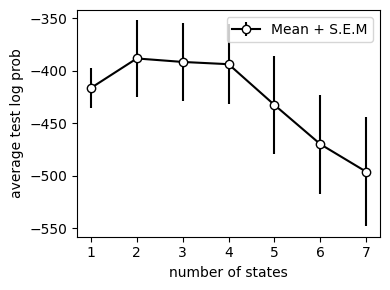

In [23]:
plt.figure(figsize = (4, 3))
plt.errorbar(state_range, avg_test_log_probs, yerr = np.array(std_test_log_probs)/np.sqrt(n_batches), mfc = 'w', color = 'k', marker = 'o')

# If you like, you can plot up each of the log_probs from the session.
#for k, test_log_probs in zip(np.arange(1, 8), all_test_log_probs):
#    plt.plot(k * np.ones(n_batches), test_log_probs, 'r.')

plt.legend(['Mean + S.E.M'])
plt.xlabel("number of states")
plt.ylabel("average test log prob")
plt.tight_layout()

best_num_states = state_range[np.argmax(avg_test_log_probs)]

print(f'Optimal number of states: {best_num_states}')

In [24]:
key = jr.PRNGKey(1)

number_of_states = best_num_states

scaler = StandardScaler()   
input_data =  behavior_data_prechange[['Mean pupil area', 'Mean speed', 'eye_y','whisker pad_y', 'ear_y', 'nose_y', 'jaw_y']].values
input_data = scaler.fit_transform(input_data)

final_hmm = GaussianHMM(number_of_states, input_data.shape[1], transition_matrix_stickiness=50.)

params, props = final_hmm.initialize(key=key, method="kmeans", emissions=input_data)

params, lps = final_hmm.fit_em(params, props, input_data, num_iters=500)

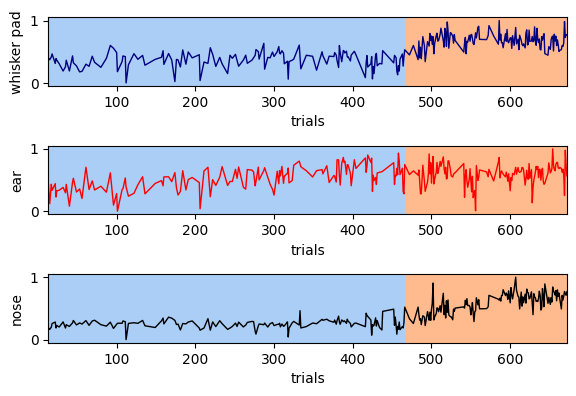

In [25]:
def minmax(x):
    # Function to normalize the data for easy visualization
    return (x - np.min(x))/(np.max(x) - np.min(x)) 

# Find the most likely discrete states given the learned model parameters
most_likely_states = final_hmm.most_likely_states(params, input_data)

# Overlay the precision and recall curves on top of the inferred states
fig, ax = plt.subplots(3, 1, figsize=(6, 4))
cmap =sns.color_palette("pastel", best_num_states)
bounds=np.arange(-0.5, best_num_states, 0.5)

# Overlay behavioral variables 
# plt.plot(pre_change_trials, minmax(mean_speed), color = 'sienna', label="Running Speed", lw = 1)
# plt.plot(pre_change_trials, minmax(mean_pupil_area), color = 'navy', label="Pupil Area", lw = 1)
ax[0].plot(pre_change_trials, minmax(mean_key_positions['whisker pad_y']), color = 'navy', label="whisker_pad", lw = 1)
ax[0].set_ylabel('whisker pad')

ax[1].plot(pre_change_trials, minmax(mean_key_positions['ear_y']), color = 'r', label="ear", lw = 1)
ax[1].set_ylabel('ear')

ax[2].plot(pre_change_trials, minmax(mean_key_positions['nose_y']), color = 'k', label="nose", lw = 1)
ax[2].set_ylabel('nose')

# Define state boundaries 
states = most_likely_states
switch_trials = np.where(np.diff(states))[0]
switch_trials = np.concatenate(([0], switch_trials, [len(go_trials)-1]))

# Plot the states 
for j in range(3):
    for i, trial in enumerate(switch_trials[:-1]):
        for state_no in range(best_num_states):
            if states[trial+1] == state_no: 
                ax[j].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], 
                           facecolor= cmap[state_no], alpha=0.9, label = 'State' + str(state_no))

    # Formatting 
    ax[j].set_xlim(go_trials[0], go_trials[-1])
    ax[j].set_xlabel("trials")

plt.tight_layout()

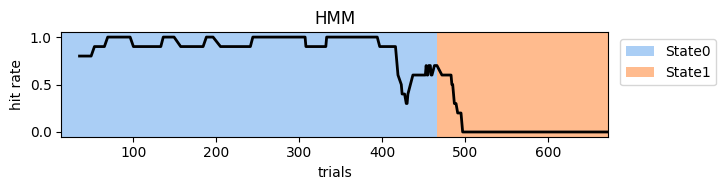

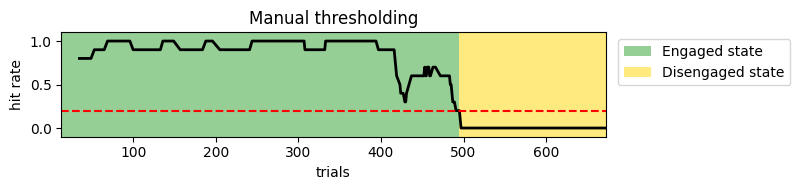

In [26]:
fig, ax = plt.subplots(figsize=(7.45, 2))
cmap = sns.color_palette("pastel", best_num_states)
bounds=np.arange(-0.5, best_num_states, 0.5)

# 1. New states: 

# Find the most likely discrete states given the learned model parameters
most_likely_states = final_hmm.most_likely_states(params, input_data)
# Define state boundaries 
states = most_likely_states
switch_trials = np.where(np.diff(states))[0]
switch_trials = np.concatenate(([0], switch_trials, [len(go_trials)-1]))

# Plot the states 
for i, trial in enumerate(switch_trials[:-1]):
    for state_no in range(best_num_states):
        if states[trial+1] == state_no: 
            ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor= cmap[state_no], alpha=0.9, label = 'State' + str(state_no))

# Overlay the hit rate
plt.plot(go_trials, hit_rate, color = 'k', lw = 2)
plt.xlim(go_trials[0], go_trials[-1])

# Formatting 
plt.xlabel("trials")
plt.ylabel('hit rate')
plt.title('HMM')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor = (1.01, 1))
plt.tight_layout()

# 2. States From WS - 1 
engagement_threshold = 0.2

# Overlay the hit rate plot
fig,ax = plt.subplots(figsize = (8.2, 2)) 
ax.plot(go_trials, hit_rate, color = 'k', lw = 2)
ax.plot(go_trials, 0.2*np.ones(len(go_trials)), color = 'r', ls = '--')

# Define state boundaries 
states = hit_rate < engagement_threshold
switch_trials = np.where(np.diff(states))[0]
switch_trials = np.concatenate(([0], switch_trials, [len(go_trials)-1]))


# Plot the states 
for i, trial in enumerate(switch_trials[:-1]):
    if not states[trial+1]: 
        ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='tab:green', alpha=0.5, label = 'Engaged state')
    else:
        ax.axvspan(go_trials[trial], go_trials[switch_trials[i+1]], facecolor='gold', alpha=0.5,label = 'Disengaged state')

# Formatting 
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(go_trials[0], go_trials[-1])
ax.set_xlabel('trials')
ax.set_ylabel('hit rate')
plt.title('Manual thresholding')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor = (1.01, 1))
plt.tight_layout()

In [27]:
# start_time of prechange to start_time of change. 
# passive table - get same index from above. 
# passive_table = stim_table[stim_table['stimulus_block']==5].reset_index()

In [28]:
# drop out different variables 
# 